# Experiment: METR-LA Exploration

This notebook is our starting point for understanding the METR-LA dataset before we choose a forecasting target, preprocessing strategy, and baseline model.

Questions to answer:
- What is the shape and time coverage of the dataset?
- How many sensors are present and how complete is the data?
- What does traffic speed look like for a few representative sensors?
- What forecasting setup should we use first?


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)


## Paths and dependency check

The METR-LA speeds live in an HDF5 file. Pandas needs the optional `tables` package to read it. This cell makes that requirement explicit so setup problems are easy to diagnose.


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() or (candidate / "data").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
data_dir = repo_root / "data" / "raw" / "METR-LA-Complete"
h5_path = data_dir / "metr-la.h5"
distances_path = data_dir / "distances_la_2012.csv"
sensor_locations_path = data_dir / "graph_sensor_locations.csv"

try:
    import tables  # noqa: F401
except ImportError as exc:
    raise RuntimeError(
        "Missing optional dependency 'tables'. Install it in the project environment before reading metr-la.h5."
    ) from exc

print(f"Repo root: {repo_root}")
print(f"HDF5 file exists: {h5_path.exists()} -> {h5_path}")


Repo root: /Users/jerry/Projects/School/intellipath-ml
HDF5 file exists: True -> /Users/jerry/Projects/School/intellipath-ml/data/raw/METR-LA-Complete/metr-la.h5


## Load the core traffic matrix

Rows are timestamps and columns are sensors. Values are traffic speeds. We also infer the sampling interval so we can decide on forecast horizons later.


In [3]:
def load_metr_la_hdf(path: Path) -> pd.DataFrame:
    with tables.open_file(path, mode="r") as h5_file:
        node = h5_file.root.df
        values = node.block0_values.read()
        columns = [
            col.decode() if isinstance(col, (bytes, bytearray)) else str(col)
            for col in node.axis0.read()
        ]
        index = pd.to_datetime(node.axis1.read())
    return pd.DataFrame(values, index=index, columns=columns).sort_index()


df = load_metr_la_hdf(h5_path)

time_deltas = df.index.to_series().diff().dropna()
sampling_interval = time_deltas.mode().iloc[0] if not time_deltas.empty else pd.NaT

print(f"Shape: {df.shape}")
print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Most common sampling interval: {sampling_interval}")
df.head()


Shape: (34272, 207)
Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Most common sampling interval: 0 days 00:05:00


,773869,767541,767542,717447,717446,717445,...,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,...,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,...,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,...,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000


## Dataset profile

This gives us a quick summary of missing values, spread, and the most incomplete sensors.


In [4]:
sensor_missing = df.isna().sum().sort_values(ascending=False)
profile = pd.Series(
    {
        "num_timestamps": df.shape[0],
        "num_sensors": df.shape[1],
        "total_missing_values": int(df.isna().sum().sum()),
        "missing_fraction": float(df.isna().mean().mean()),
        "global_mean_speed": float(df.stack().mean()),
        "global_std_speed": float(df.stack().std()),
        "global_min_speed": float(df.stack().min()),
        "global_max_speed": float(df.stack().max()),
    }
)

display(profile.to_frame("value"))
display(sensor_missing.head(10).to_frame("missing_values"))


,value
num_timestamps,34272.000000
num_sensors,207.000000
total_missing_values,0.000000
missing_fraction,0.000000
global_mean_speed,53.719021
global_std_speed,20.261432
global_min_speed,0.000000
global_max_speed,70.000000


,missing_values
773869,0
773904,0
762329,0
716953,0
716951,0
767509,0
765182,0
769358,0
772513,0
716958,0


## Summary statistics by sensor

Looking across sensors helps us spot outliers or strange ranges before we train anything.


In [5]:
sensor_stats = df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
sensor_stats.sort_values("mean").head(10)


,mean,std,min,25%,50%,75%,max
771667,28.310130,10.084643,0.0,25.875000,31.000000,34.555556,70.000000
771673,30.006009,10.437928,0.0,28.375000,32.777778,35.777778,70.000000
716955,32.738368,17.721576,0.0,20.375000,40.118056,44.500000,70.000000
773023,36.039058,16.291562,0.0,24.125000,33.777778,51.500000,66.571429
716339,37.780363,24.624651,0.0,16.625000,23.444444,64.375000,70.000000
772167,37.803342,13.525743,0.0,30.444444,43.222222,46.625000,65.000000
764853,38.114083,19.478477,0.0,19.875000,40.444444,57.000000,70.000000
769405,40.435995,18.889680,0.0,36.250000,49.375000,52.000000,70.000000
717458,40.855190,24.515366,0.0,17.111111,54.111111,64.500000,70.000000
773012,41.168496,15.068436,0.0,43.750000,45.000000,46.666667,70.000000


## Plot a few sensor time series

A small random sample is enough to verify seasonality, spikes, and missing stretches.


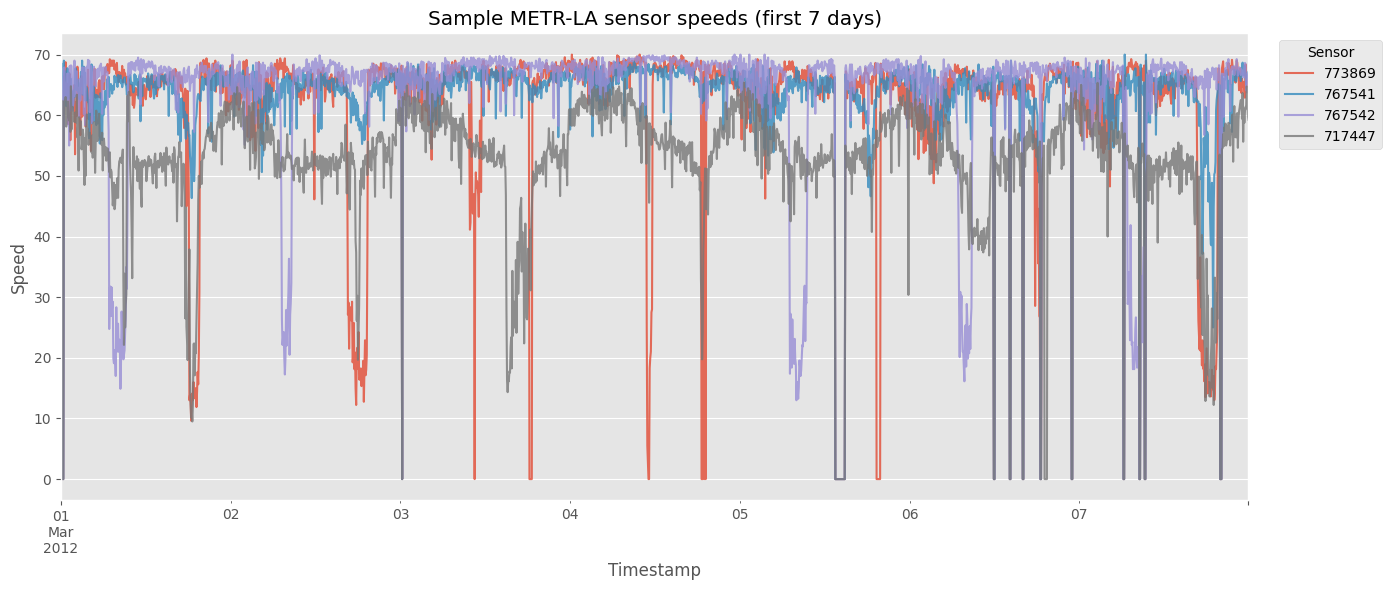

In [6]:
sample_sensor_count = min(4, df.shape[1])
sample_sensors = list(df.columns[:sample_sensor_count])

ax = df[sample_sensors].iloc[: 24 * 12 * 7].plot(figsize=(14, 6), alpha=0.8)
ax.set_title("Sample METR-LA sensor speeds (first 7 days)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Speed")
plt.legend(title="Sensor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## Aggregate daily pattern

This view helps us see whether there is a strong repeating daily traffic rhythm, which is useful for both baselines and feature engineering.


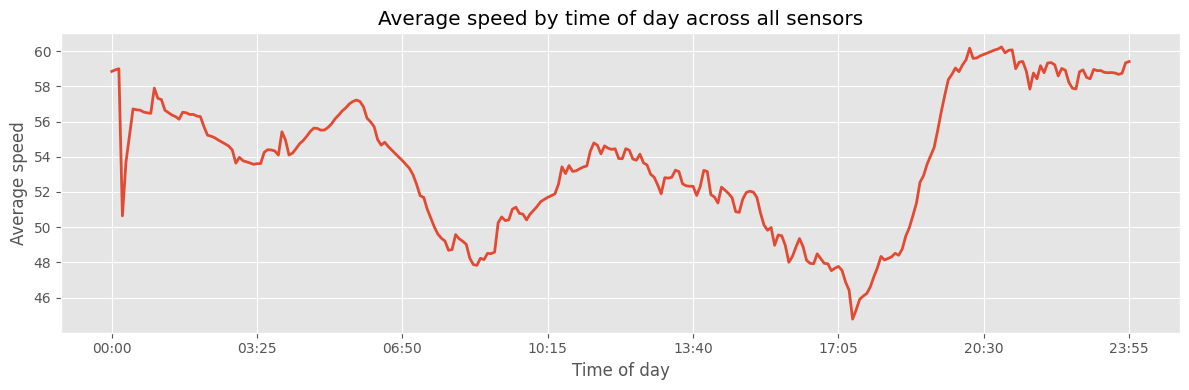

In [7]:
average_by_time = df.groupby(df.index.time).mean().mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(average_by_time)), average_by_time.values, linewidth=2)
tick_positions = np.linspace(0, len(average_by_time) - 1, 8, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([average_by_time.index[i].strftime("%H:%M") for i in tick_positions])
ax.set_title("Average speed by time of day across all sensors")
ax.set_xlabel("Time of day")
ax.set_ylabel("Average speed")
plt.tight_layout()


## Optional metadata tables

These files are useful later when we connect sensors spatially or build graph-aware models.


In [8]:
sensor_locations = pd.read_csv(sensor_locations_path)
distances = pd.read_csv(distances_path)

print(f"Sensor locations shape: {sensor_locations.shape}")
print(f"Distances shape: {distances.shape}")
display(sensor_locations.head())
display(distances.head())


Sensor locations shape: (207, 4)
Distances shape: (295374, 3)


,index,sensor_id,latitude,longitude
0,0,773869,34.15497,-118.31829
1,1,767541,34.11621,-118.23799
2,2,767542,34.11641,-118.23819
3,3,717447,34.07248,-118.26772
4,4,717446,34.07142,-118.26572


,from,to,cost
0,1201054,1201054,0.0
1,1201054,1201066,2610.9
2,1201054,1201076,2822.7
3,1201054,1201087,2911.5
4,1201054,1201100,7160.1


## Initial recommendation

Based on the course scope and the structure of METR-LA, a strong first milestone is:
- Task: short-horizon traffic speed forecasting
- Target: each sensor's speed 15 to 60 minutes ahead
- Split: chronological train/validation/test split
- Baseline: persistence model (predict the next value from the current value)

After running the notebook, fill in the notes below.


In [9]:
notes = {
    "target_variable": "traffic speed",
    "forecast_horizon": "TODO",
    "split_strategy": "chronological",
    "baseline_model": "persistence / last observed value",
    "observations": [
        "TODO: summarize shape and coverage",
        "TODO: summarize missing-data issues",
        "TODO: summarize daily traffic pattern",
    ],
}
notes


{'target_variable': 'traffic speed',
 'forecast_horizon': 'TODO',
 'split_strategy': 'chronological',
 'baseline_model': 'persistence / last observed value',
 'observations': ['TODO: summarize shape and coverage',
  'TODO: summarize missing-data issues',
  'TODO: summarize daily traffic pattern']}